# Sprint 3 Demo

This notebook demonstrates the Sprint 3 evaluation, structured output, SHAP explanation, and prototype prediction workflow using the saved no-leakage Random Forest artifacts from Sprint 2/3.

In [1]:
from pathlib import Path
import pickle
import sys

import joblib
import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.modeling.evaluation import (
    build_evaluation_table,
    evaluate_model,
    save_confusion_matrix_plot,
    save_model_comparison_plot,
    save_roc_curve,
)
from src.output.prediction_output import save_model_prediction_output
from src.explainability.shap_explainer import (
    save_global_shap_importance_plot,
    save_global_shap_importance_table,
    save_global_shap_summary,
    save_selected_local_explanations,
)
from src.prototype.predict_explain import predict_and_explain_case

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Final No-Leakage Model Artifacts

In [2]:
artifact_dir = project_root / "models" / "shap_inputs"

best_rf = joblib.load(artifact_dir / "best_rf.joblib")
X_test_no_leakage = joblib.load(artifact_dir / "X_test_no_leakage.joblib")
y_test = joblib.load(artifact_dir / "y_test.joblib")

with open(artifact_dir / "feature_columns_no_leakage.pkl", "rb") as file:
    feature_columns_no_leakage = pickle.load(file)

case_ids_test = [f"test_case_{index}" for index in range(X_test_no_leakage.shape[0])]

print("Model:", type(best_rf).__name__)
print("Feature matrix:", X_test_no_leakage.shape)
print("Labels:", len(y_test))
print("Feature names:", len(feature_columns_no_leakage))

Model: RandomForestClassifier
Feature matrix: (1134, 121)
Labels: 1134
Feature names: 121


## Evaluate Model

In [3]:
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
explanations_dir = figures_dir / "explanations"

reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
explanations_dir.mkdir(parents=True, exist_ok=True)

y_pred = best_rf.predict(X_test_no_leakage)
y_score = best_rf.predict_proba(X_test_no_leakage)[:, 1]

rf_metrics = evaluate_model(
    best_rf,
    X_test_no_leakage,
    y_test,
    "Random Forest no-leakage",
)
comparison_table = build_evaluation_table([rf_metrics])
comparison_path = reports_dir / "model_comparison_sprint3.csv"
comparison_table.to_csv(comparison_path, index=False)

roc_curve_path = save_roc_curve(
    y_test,
    y_score,
    "Random Forest no-leakage",
    figures_dir / "roc_curve_sprint3.png",
)
confusion_matrix_path = save_confusion_matrix_plot(
    y_test,
    y_pred,
    "Random Forest no-leakage",
    figures_dir / "confusion_matrix_sprint3.png",
)
model_comparison_plot_path = save_model_comparison_plot(
    comparison_table,
    figures_dir / "model_comparison_sprint3.png",
)

comparison_table

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest no-leakage,0.670194,0.962756,0.593571,0.734375,0.881516


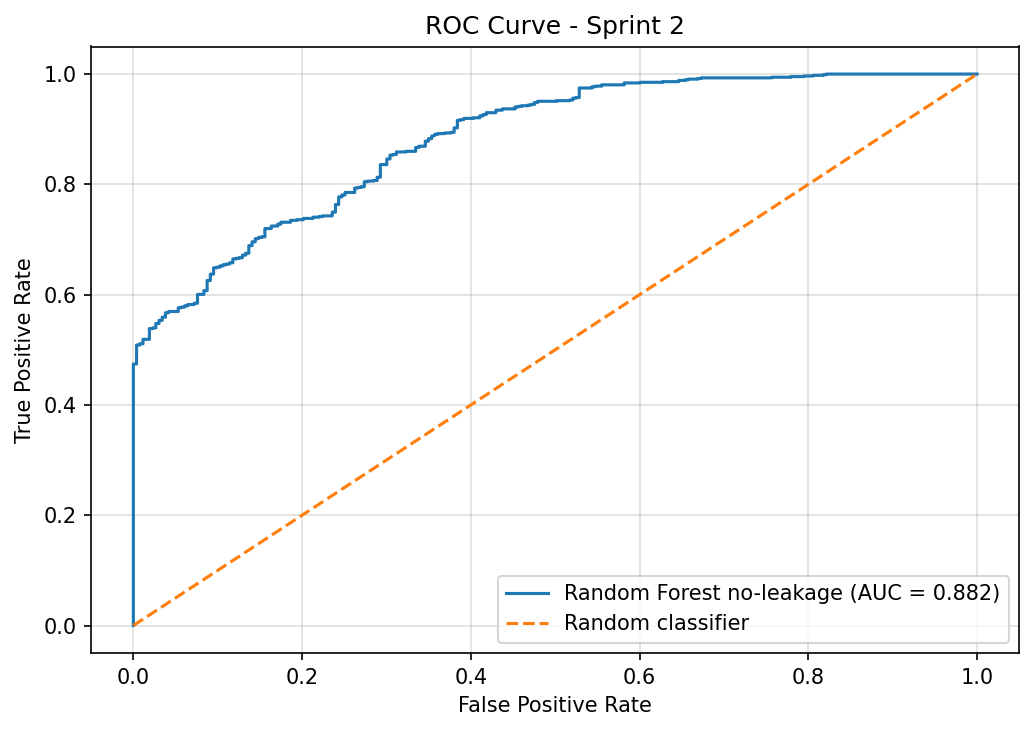

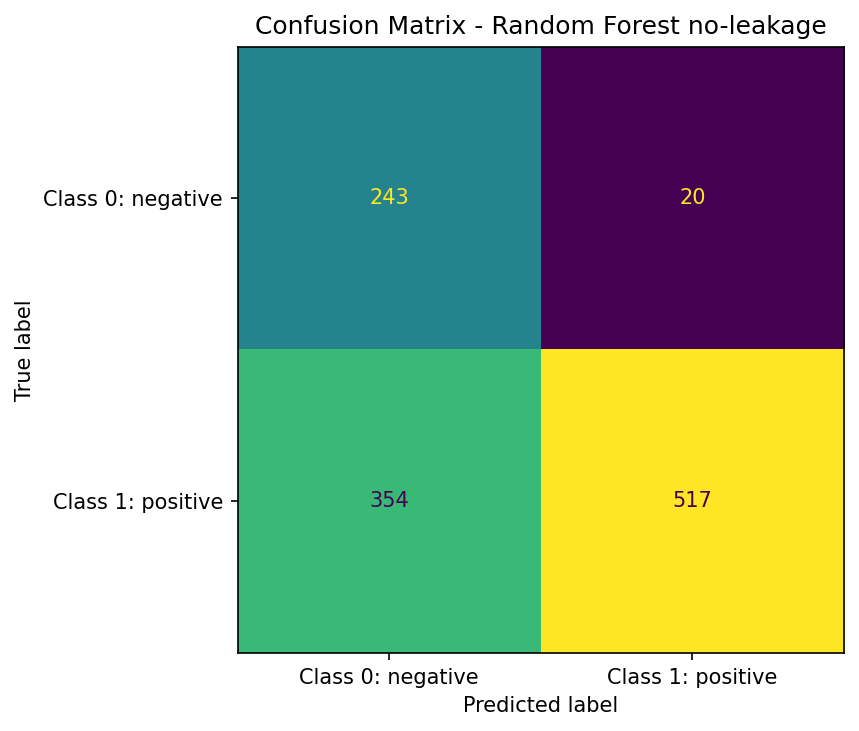

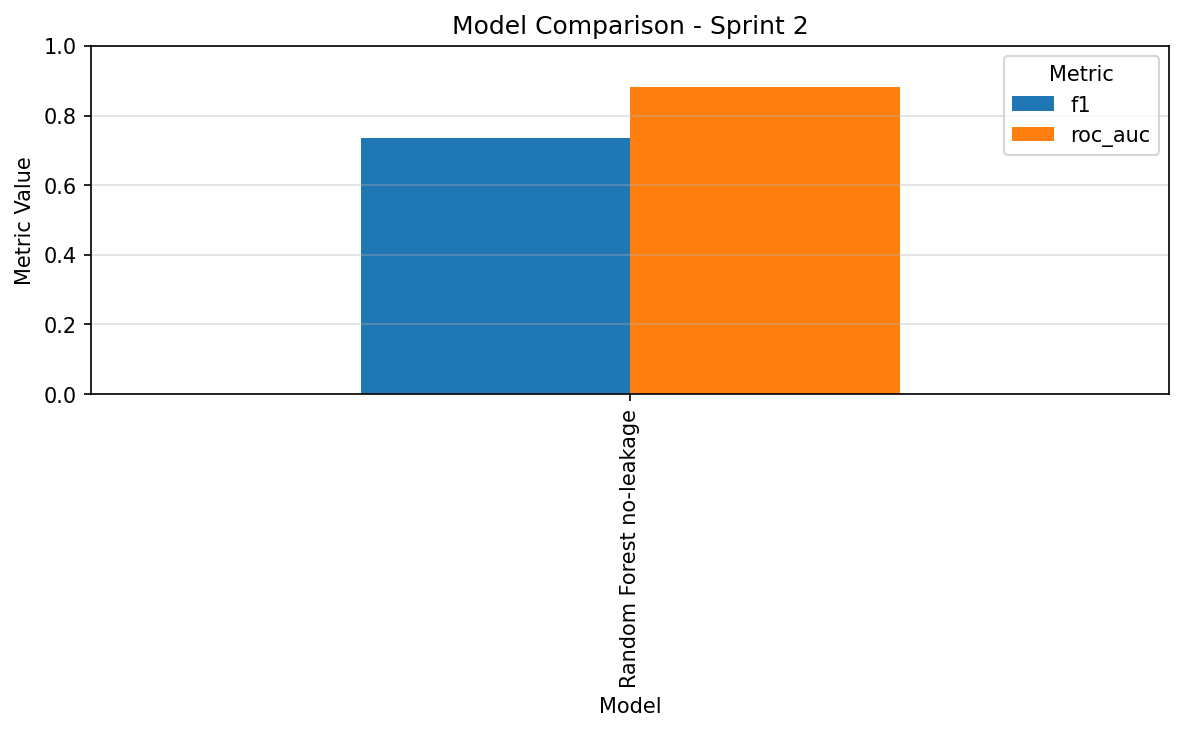

In [4]:
display(Image(filename=str(roc_curve_path)))
display(Image(filename=str(confusion_matrix_path)))
display(Image(filename=str(model_comparison_plot_path)))

## Save Structured Prediction Output

In [5]:
prediction_output = save_model_prediction_output(
    model=best_rf,
    features=X_test_no_leakage,
    case_ids=case_ids_test,
    y_true=y_test,
    model_name="Random Forest no-leakage",
    model_type="black_box",
    dataset_split="test",
    threshold=0.5,
    sprint="sprint3",
    output_path=reports_dir / "predictions_sprint3.csv",
)

prediction_output.head()

,case_id,y_true,prediction,probability,model,model_type,dataset_split,threshold,sprint
0,test_case_0,False,False,0.414581,Random Forest no-leakage,black_box,test,0.5,sprint3
1,test_case_1,True,False,0.344309,Random Forest no-leakage,black_box,test,0.5,sprint3
2,test_case_2,False,False,0.415556,Random Forest no-leakage,black_box,test,0.5,sprint3
3,test_case_3,True,False,0.376819,Random Forest no-leakage,black_box,test,0.5,sprint3
4,test_case_4,False,False,0.354592,Random Forest no-leakage,black_box,test,0.5,sprint3


## Generate SHAP Explanations

In [6]:
shap_summary_path = save_global_shap_summary(
    best_rf,
    X_test_no_leakage,
    feature_columns_no_leakage,
    explanations_dir / "shap_summary_sprint3.png",
    max_samples=300,
)
shap_importance_table = save_global_shap_importance_table(
    best_rf,
    X_test_no_leakage,
    feature_columns_no_leakage,
    reports_dir / "shap_feature_importance_sprint3.csv",
    max_samples=300,
)
shap_importance_plot_path = save_global_shap_importance_plot(
    best_rf,
    X_test_no_leakage,
    feature_columns_no_leakage,
    explanations_dir / "shap_importance_bar_sprint3.png",
    max_samples=300,
    top_n=15,
)
local_shap_paths = save_selected_local_explanations(
    best_rf,
    X_test_no_leakage,
    feature_columns_no_leakage,
    y_test,
    y_pred,
    explanations_dir,
)

shap_importance_table.head(10)

,feature,mean_abs_shap
114,month_std,0.041332
101,day_of_week_max,0.039031
102,day_of_week_std,0.036544
112,month_min,0.031806
111,month_mean,0.029163
78,concept:name=Completed,0.022567
0,resource country=0,0.019359
99,day_of_week_mean,0.017693
97,hour_count,0.017392
85,concept:name_transition=Completed->Completed,0.017381


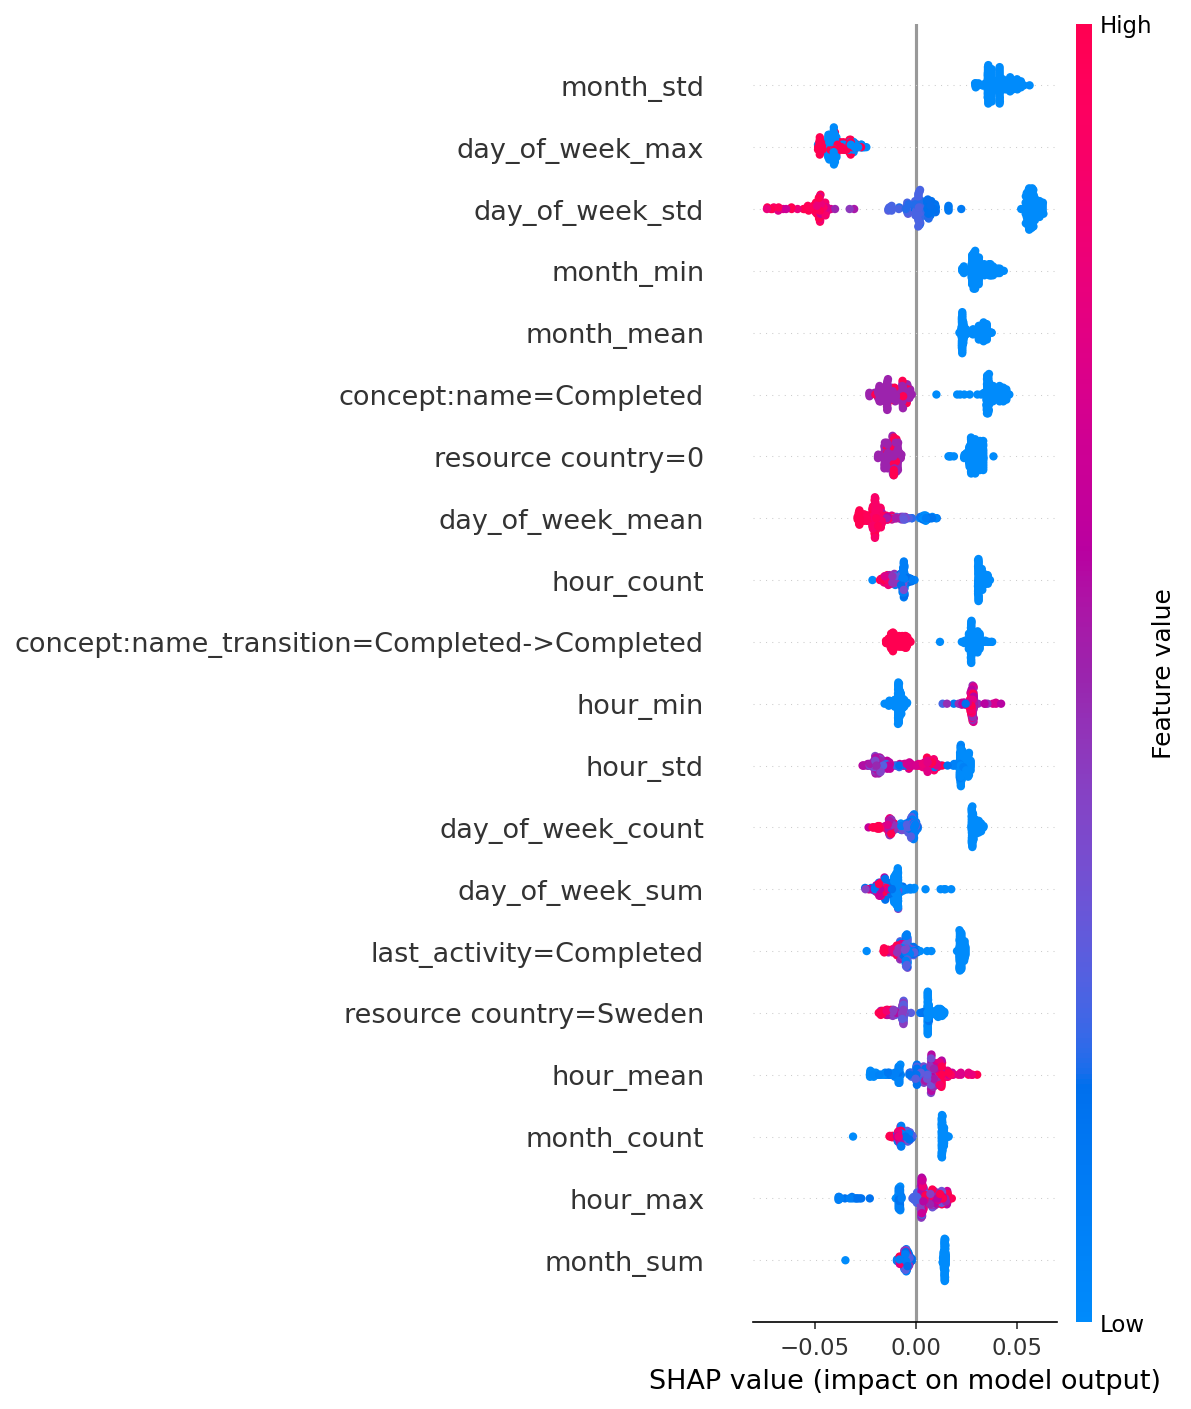

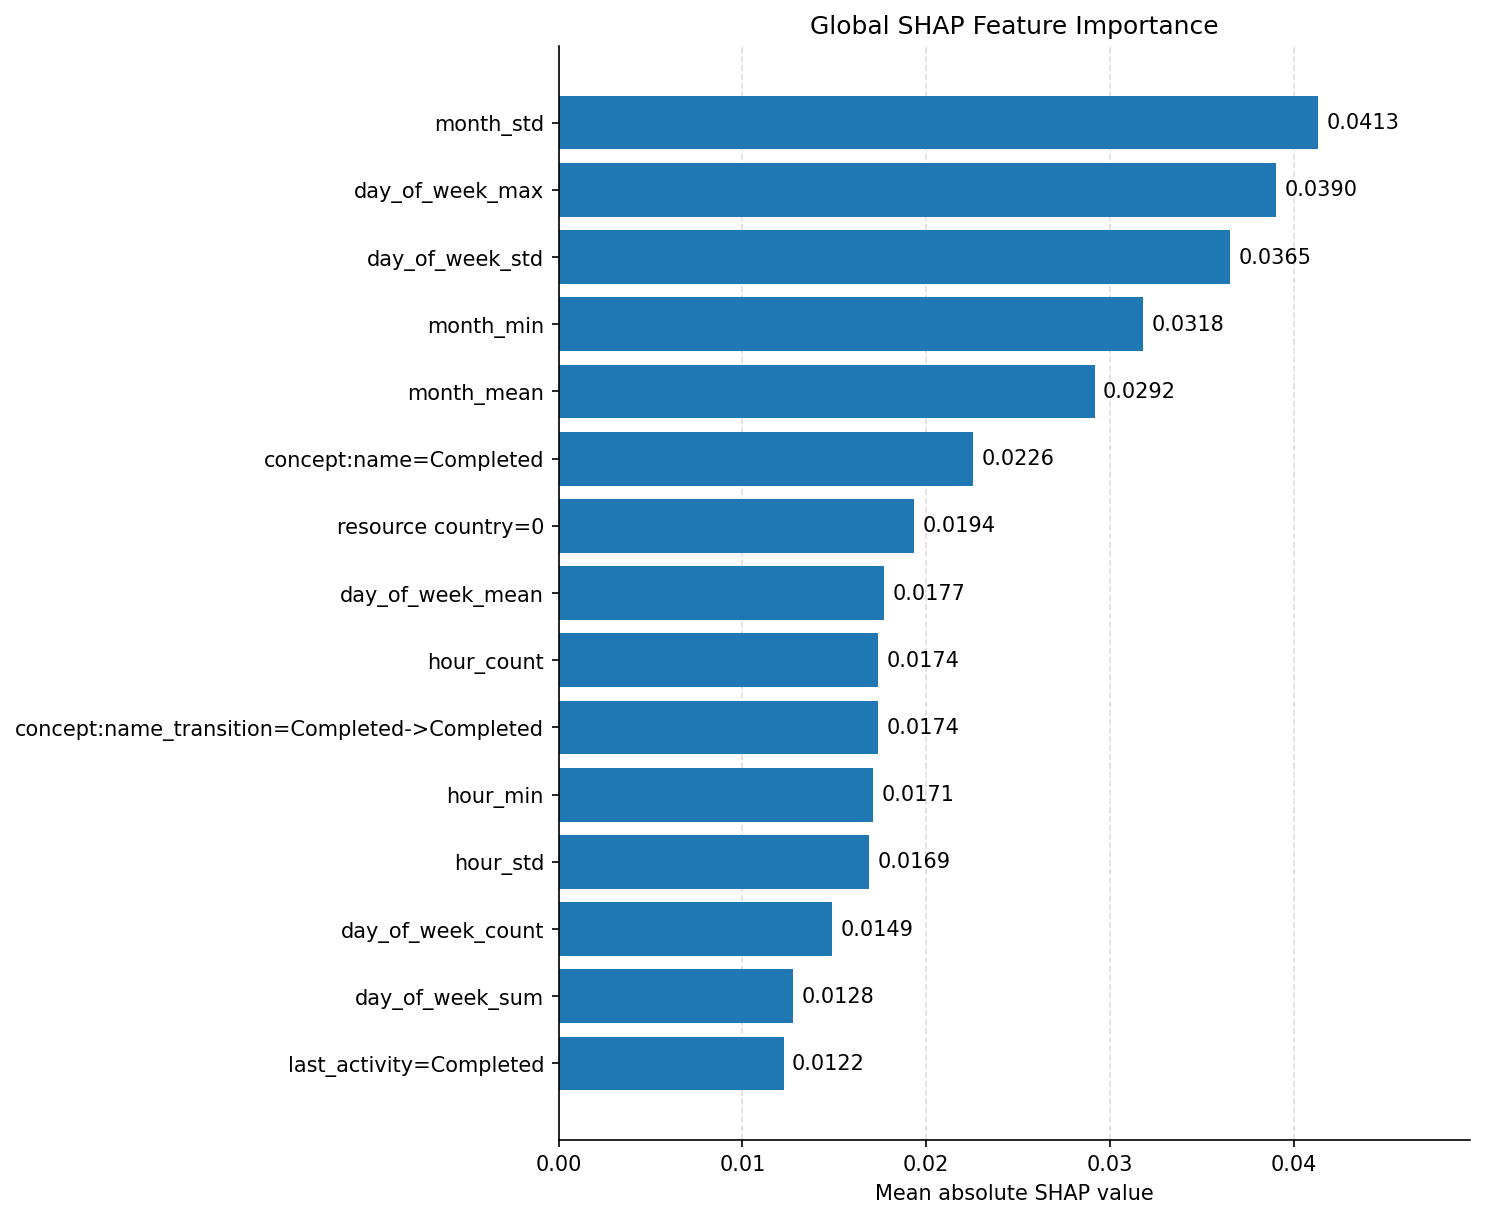

correct_positive /Users/alex/Documents/RWTH/4Semester/spp/project/explainable-process-prediction/figures/explanations/shap_local_correct_positive.png


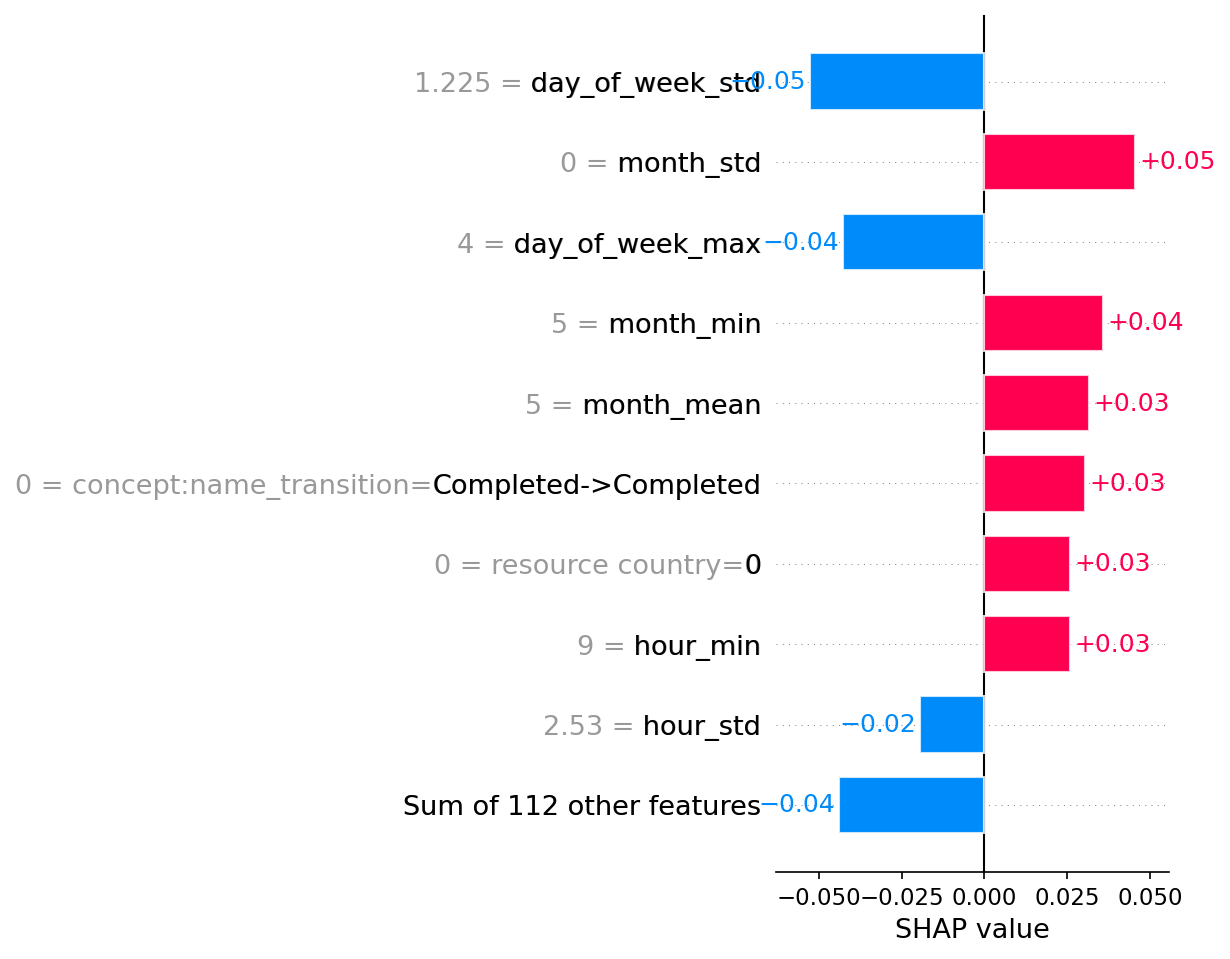

correct_negative /Users/alex/Documents/RWTH/4Semester/spp/project/explainable-process-prediction/figures/explanations/shap_local_correct_negative.png


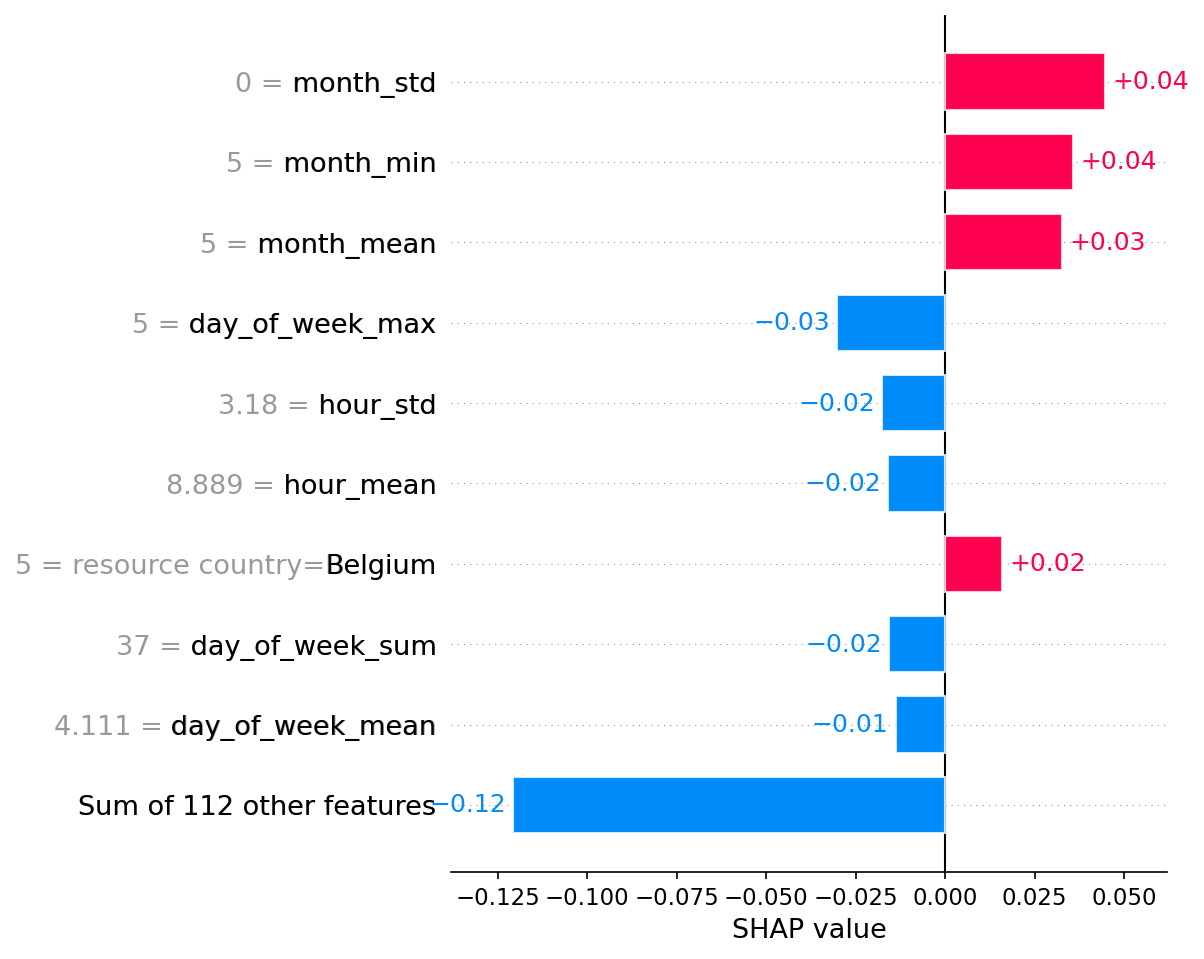

misclassified /Users/alex/Documents/RWTH/4Semester/spp/project/explainable-process-prediction/figures/explanations/shap_local_misclassified.png


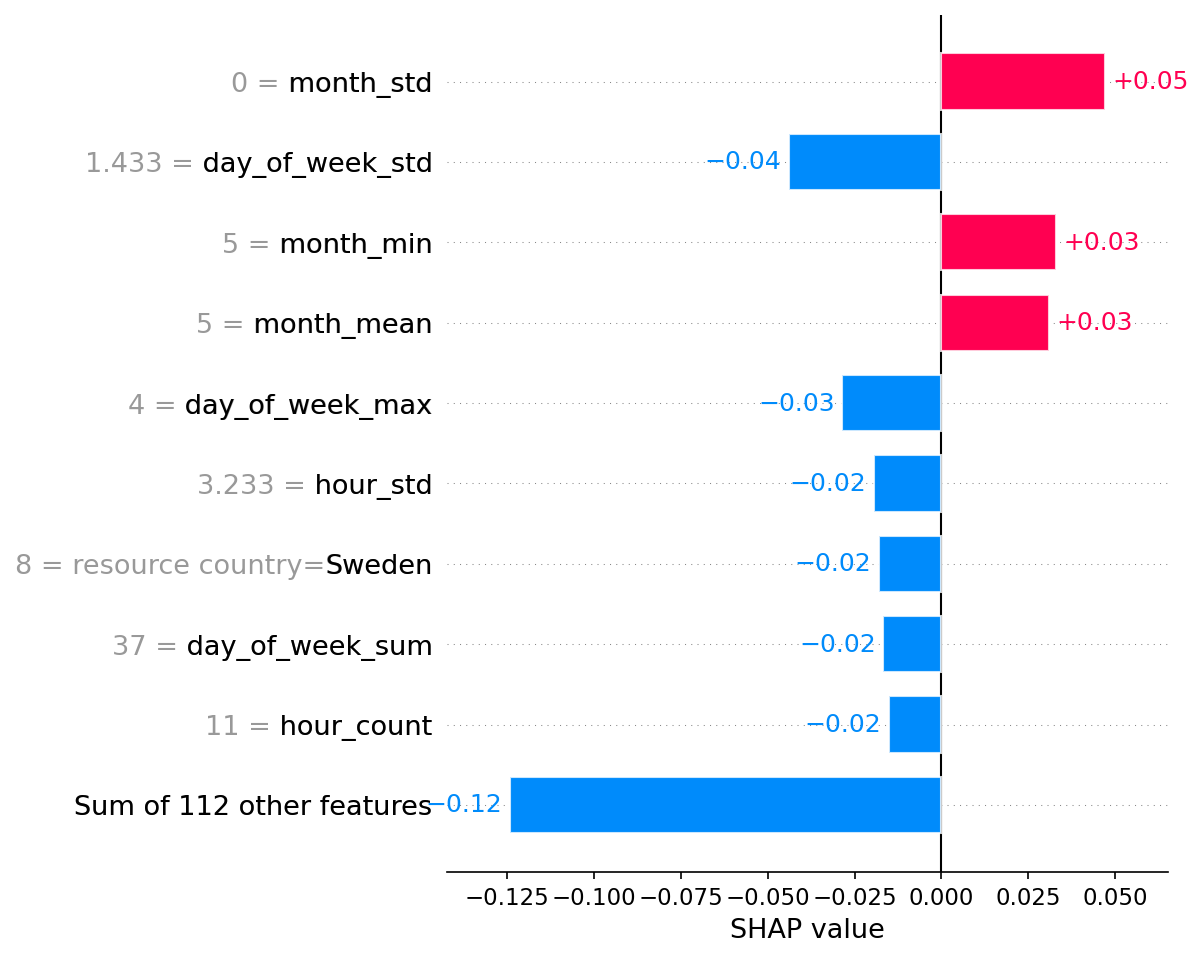

In [7]:
display(Image(filename=str(shap_summary_path)))
display(Image(filename=str(shap_importance_plot_path)))

for case_type, path in local_shap_paths.items():
    print(case_type, path)
    display(Image(filename=str(path)))

## Prototype Prediction And Explanation

In [8]:
prototype_result = predict_and_explain_case(
    model=best_rf,
    case_features=X_test_no_leakage[0],
    feature_columns=feature_columns_no_leakage,
    case_id=case_ids_test[0],
    top_n=5,
    local_plot_path=explanations_dir / "prototype_case_0_sprint3.png",
)

prototype_result

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


{'case_id': 'test_case_0',
 'predicted_class': 0,
 'prediction_probability': 0.41458054866683397,
 'top_features': [{'feature': 'month_std',
   'value': 0.0,
   'shap_value': 0.044696235026125755,
   'abs_shap_value': 0.044696235026125755},
  {'feature': 'month_min',
   'value': 5.0,
   'shap_value': 0.03582360886320396,
   'abs_shap_value': 0.03582360886320396},
  {'feature': 'month_mean',
   'value': 5.0,
   'shap_value': 0.03271969447269572,
   'abs_shap_value': 0.03271969447269572},
  {'feature': 'day_of_week_max',
   'value': 5.0,
   'shap_value': -0.030160209566798983,
   'abs_shap_value': 0.030160209566798983},
  {'feature': 'hour_std',
   'value': 3.1797973380564852,
   'shap_value': -0.017623997559440184,
   'abs_shap_value': 0.017623997559440184}],
 'local_plot_path': '/Users/alex/Documents/RWTH/4Semester/spp/project/explainable-process-prediction/figures/explanations/prototype_case_0_sprint3.png'}

## Output Existence Check

In [9]:
expected_outputs = [
    reports_dir / "model_comparison_sprint3.csv",
    reports_dir / "predictions_sprint3.csv",
    reports_dir / "shap_feature_importance_sprint3.csv",
    figures_dir / "roc_curve_sprint3.png",
    figures_dir / "confusion_matrix_sprint3.png",
    figures_dir / "model_comparison_sprint3.png",
    explanations_dir / "shap_summary_sprint3.png",
    explanations_dir / "shap_importance_bar_sprint3.png",
    explanations_dir / "prototype_case_0_sprint3.png",
]

missing_outputs = [path for path in expected_outputs if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f"Missing demo outputs: {missing_outputs}")

pd.DataFrame({"output_path": expected_outputs, "exists": [path.exists() for path in expected_outputs]})

,output_path,exists
0,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
1,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
2,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
3,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
4,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
5,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
6,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
7,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
8,/Users/alex/Documents/RWTH/4Semester/spp/proje...,True
